# E1 · Compound options and staged protection

**Optional decision:** What does a buyer pay now for the right to buy protection later? Read M6 and Notebook 2 first; allow 10–15 minutes. This is an independent hypothetical example using M6's tradable proxy, not a real compute offer or an equipment-deployment commitment.

The proxy starts at USD 5 per normalized unit. Each one-year step multiplies price by 1.2 or 0.8; the effective annual risk-free rate is 5%. A call struck at USD 5 expires in year 2. Instead of buying that call immediately, buy a right now to acquire it in year 1 for an exercise fee of USD 0.50.

There are three possible cash events: initial compound premium, later exercise payment, and final call payoff. Keep those events distinct from the model values used to decide whether exercise is worthwhile.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.option_valuation import compound_call_value
from liquid_compute.options import option_cash_flows, staged_option_cash_flows

model = dict(
    spot_usd_per_unit=5.0,
    strike_usd_per_unit=5.0,
    up_factor=1.2,
    down_factor=0.8,
    effective_annual_rate=0.05,
    step_years=1.0,
)
exercise_fee = 0.50
exercise_month = 12
expiry_month = 24
print("Year 1 = month 12 purchase decision; year 2 = month 24 final payoff.")

Year 1 = month 12 purchase decision; year 2 = month 24 final payoff.


## Value the underlying call at the decision date

Retain M6's pricing up weight q=0.625. At year 2 the proxy prices are 3.2, 4.8 and 7.2, giving call payoffs 0, 0 and 2.2. At the year-1 up node, the remaining call is worth (0.625 × 2.2)/1.05 = USD 1.3095238. At the down node both possible final payoffs are zero, so its value is zero.

These are values of the remaining call, not cash distributions. The owner of a call worth USD 1.3095238 has not automatically received that amount in a bank account.

In [3]:
q = (1.05 - 0.8) / (1.2 - 0.8)
up_call_value = (
    q * max(5 * 1.2 * 1.2 - 5, 0) + (1 - q) * max(5 * 1.2 * 0.8 - 5, 0)
) / 1.05
down_call_value = 0.0
show_finance_table(
    ["Year-1 node", "Underlying call value USD/unit"],
    [["Down", down_call_value], ["Up", up_call_value]],
)
print(f"Up-node value: USD {up_call_value:.7f}")

| Year-1 node | Underlying call value USD/unit |
| --- | --- |
| Down | 0.00 |
| Up | 1.31 |

Up-node value: USD 1.3095238


## Value the right to purchase that call

At each year-1 node, the purchase right has value max(call value−fee, 0). The down-node surplus is zero; the up-node surplus is USD 0.8095238. Discount the pricing-weighted surplus once more: 0.625 × 0.8095238 / 1.05 = USD 0.4818594.

Buying the underlying call immediately instead costs USD 0.7794785 in the same two-year model. The smaller initial compound premium is not free protection. It purchases a later choice that requires another payment and may leave the buyer without a call.

In [4]:
down_surplus = max(down_call_value - exercise_fee, 0)
up_surplus = max(up_call_value - exercise_fee, 0)
direct_premium = (q * up_surplus + (1 - q) * down_surplus) / 1.05
immediate_value = (q * up_call_value + (1 - q) * down_call_value) / 1.05
result = compound_call_value(**model, exercise_fee_usd_per_unit=exercise_fee)
show_finance_table(
    ["Time-zero model value", "USD/unit"],
    [
        ["Direct compound calculation", direct_premium],
        ["Shared compound calculator", result.premium_usd],
        ["Immediate call purchase", immediate_value],
    ],
)
print(
    f"Compound premium: USD {result.premium_usd:.7f}; immediate call: USD {immediate_value:.7f}"
)

| Time-zero model value | USD/unit |
| --- | --- |
| Direct compound calculation | 0.48 |
| Shared compound calculator | 0.48 |
| Immediate call purchase | 0.78 |

Compound premium: USD 0.4818594; immediate call: USD 0.7794785


## Follow actual cash on an up/up path

The shared calculator reuses M6's tree and backward recursion. Its exercise policy buys the call only where its value exceeds the fee. At exact equality, we choose no exercise because either choice has the same model value.

On an up/up path, actual cash is −0.4818594 now, −0.50 at month 12, and +2.20 at month 24. Do not add the USD 0.8095238 node surplus as another receipt. The optional control changes the fee and recomputes both premium and exercise policy, while fixed experiments retain their own inputs.

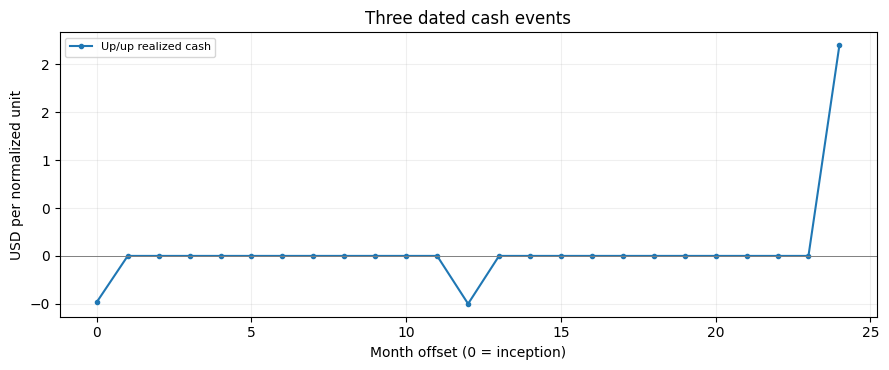

In [5]:
def path_cash(
    value, first_up, terminal_price, exercise=exercise_month, expiry=expiry_month
):
    return staged_option_cash_flows(
        premium_usd=value.premium_usd,
        exercise_fee_usd=value.exercise_fee_usd_per_unit,
        exercise_month=exercise,
        expiry_month=expiry,
        exercised=value.exercise_at_node[int(first_up)],
        settlement_price_usd_per_unit=terminal_price,
        strike_usd_per_unit=5,
    )


up_up = path_cash(result, True, 7.2)
display(
    plot_finance_series(
        {"Up/up realized cash": [r.net_cash_usd for r in up_up]},
        title="Three dated cash events",
        ylabel="USD per normalized unit",
    )
)


def staged_explorer(values, baseline=model.copy()):
    from liquid_compute.option_valuation import compound_call_value

    value = compound_call_value(
        **baseline, exercise_fee_usd_per_unit=values["Exercise fee USD/unit"]
    )
    rows = staged_option_cash_flows(
        premium_usd=value.premium_usd,
        exercise_fee_usd=value.exercise_fee_usd_per_unit,
        exercise_month=12,
        expiry_month=24,
        exercised=value.exercise_at_node[1],
        settlement_price_usd_per_unit=7.2,
        strike_usd_per_unit=5,
    )
    return {
        f"Up/up cash; premium {value.premium_usd:.7f}": [r.net_cash_usd for r in rows]
    }


explore_finance_series(
    {"Exercise fee USD/unit": 0.50},
    staged_explorer,
    title="Staged purchase on an up/up path",
    ylabel="USD per normalized unit",
);

The chart separates premium, purchase fee and final payout on their actual dates. It is a realized path, not an expected outcome or present value. Even after exercise, a later down move can leave the acquired call worthless.

## Experiment 1 · Raise the exercise fee

Compare fees 0.50, 1.00 and 2.00. A larger fee makes the future purchase less attractive, lowering the value of the right bought today. If the fee exceeds the up-node call value, neither node justifies exercise. This conclusion depends on the declared finite tree.

In [6]:
fee_cases = [
    compound_call_value(**model, exercise_fee_usd_per_unit=fee)
    for fee in (0.50, 1.00, 2.00)
]
show_finance_table(
    [
        "Fee USD/unit",
        "Initial premium USD/unit",
        "Exercise after down?",
        "Exercise after up?",
    ],
    [
        [
            r.exercise_fee_usd_per_unit,
            r.premium_usd,
            str(r.exercise_at_node[0]),
            str(r.exercise_at_node[1]),
        ]
        for r in fee_cases
    ],
)

| Fee USD/unit | Initial premium USD/unit | Exercise after down? | Exercise after up? |
| --- | --- | --- | --- |
| 0.50 | 0.48 | False | True |
| 1.00 | 0.18 | False | True |
| 2.00 | 0.00 | False | False |

At fee 1.00 the premium falls to USD 0.1842404; up-node exercise still occurs. At fee 2.00 the premium is zero and neither node exercises. A smaller premium can therefore describe a less useful right, not a bargain.

## Experiment 2 · Make the later fee zero

With no exercise fee, the purchase right has the same model value as the underlying call. At the down node the underlying call itself has zero value, so declining a free worthless call changes nothing. This is a model-value equivalence, not a promise that every commercial staged contract has identical terms.

In [7]:
free_exercise = compound_call_value(**model, exercise_fee_usd_per_unit=0)
show_finance_table(
    ["Zero-fee comparison", "USD/unit"],
    [
        ["Compound value", free_exercise.premium_usd],
        ["Immediate underlying call value", free_exercise.immediate_call_value_usd],
        [
            "Difference",
            free_exercise.premium_usd - free_exercise.immediate_call_value_usd,
        ],
    ],
)

| Zero-fee comparison | USD/unit |
| --- | --- |
| Compound value | 0.78 |
| Immediate underlying call value | 0.78 |
| Difference | 0.00 |

Both zero-fee values are USD 0.7794785. The equivalence follows from buying the same remaining claim without an additional cost.

## Experiment 3 · Realize a down-first path

Restore fee 0.50. After a first down move, the financial exercise policy declines to buy the call. A following up move reaches 4.8 and still produces no final payoff. The initial compound premium remains spent.

Compare immediate protection on the same path. That call also expires worthless, but its larger premium was paid initially. A business launch decision is separate: canceling a project does not refund the option premium or automatically change financial exercise value.

In [8]:
down_up = path_cash(result, False, 4.8)
immediate_down = option_cash_flows(
    kind="call",
    settlement_price_usd_per_gpu_hour=4.8,
    strike_usd_per_gpu_hour=5,
    covered_gpu_hours=1,
    premium_usd_per_gpu_hour=result.immediate_call_value_usd,
    expiry_month=24,
)
show_finance_table(
    [
        "Down/up path",
        "Initial premium cash USD",
        "Exercise cash USD",
        "Final payoff USD",
        "Nominal total USD",
    ],
    [
        [
            "Staged",
            down_up[0].premium_cash_usd,
            down_up[12].exercise_cash_usd,
            down_up[-1].payoff_cash_usd,
            sum(r.net_cash_usd for r in down_up),
        ],
        [
            "Immediate",
            immediate_down[0].premium_cash_usd,
            0,
            immediate_down[-1].payoff_cash_usd,
            sum(r.net_cash_usd for r in immediate_down),
        ],
    ],
)

| Down/up path | Initial premium cash USD | Exercise cash USD | Final payoff USD | Nominal total USD |
| --- | --- | --- | --- | --- |
| Staged | -0.48 | 0.00 | 0.00 | -0.48 |
| Immediate | -0.78 | 0.00 | 0.00 | -0.78 |

The down-first staged path loses USD 0.4818594; immediate purchase loses USD 0.7794785. This selected path does not prove staged protection is always cheaper. On an exercised path, the later fee also matters, and cash paid at different dates requires discounting for a value comparison.

## Keep the staged decision optional

Use the summary to distinguish initial commitment, contingent purchase and final claim. No model probability has been replaced with a business forecast. The result assumes M6's frictionless tradable proxy and funding access; it says nothing about an actual provider accepting these terms.

In [9]:
show_finance_table(
    ["Previously calculated case", "Initial model premium USD/unit"],
    [
        ["Immediate protection", result.immediate_call_value_usd],
        ["Staged fee 0.50", result.premium_usd],
        ["Staged fee 1.00", fee_cases[1].premium_usd],
        ["Staged fee zero", free_exercise.premium_usd],
    ],
)

| Previously calculated case | Initial model premium USD/unit |
| --- | --- |
| Immediate protection | 0.78 |
| Staged fee 0.50 | 0.48 |
| Staged fee 1.00 | 0.18 |
| Staged fee zero | 0.78 |

**Next:** return to M7 for the core liquidity discussion, or continue to optional E2 on minimum revenue and shared upside. E1 is not required for the planned capstone unless staged protection is selected.

[Damodaran's NYU chapter, page 108](https://pages.stern.nyu.edu/~adamodar/pdfiles/val3ed/c05.pdf) describes compound options as options on other options. The original Geske paper could not be retrieved in this pass; no claim is made to reproduce its continuous-time formula. Our two-step arithmetic is derived here from M6's shared recursion. Fees and prices are hypothetical; default, transaction costs and physical compute delivery are excluded.